# Stock Direction v10: Tree Models Benchmark

This notebook keeps the stronger parts of `v8` and avoids the over-complexity from `v9`:
- two-stage setup: `trade / no-trade` and then `direction`,
- compact feature space based on the `v8` dataset,
- fixed honest validation: rolling `12M train / 3M validation` plus final `6M` holdout,
- model-family comparison focused on tree models, with logistic regression kept only as a baseline.

The objective is not to force more complexity into the strategy, but to check whether non-linear tree models can extract a stronger and more stable signal than the linear `v8` setup.


In [9]:
from itertools import product
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_MONTHS = 12
VAL_MONTHS = 3
LAGS = [1, 2, 5]
MOVE_BAND = 0.0075
TOP_K_MOVE_VALUES = [6, 8]
TOP_K_DIR_VALUES = [6, 8]
MOVE_PROB_THRESHOLDS = [0.55, 0.60]
DIR_PROB_THRESHOLDS = [0.55, 0.60]
TARGET_ACTIVE_PCT = 0.10
MIN_STAGE2_SAMPLES = 30
TRADING_COST_ONE_WAY = 0.0005

BASE_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "realized_vol_5d",
    "realized_vol_10d",
    "price_vs_sma_5d",
    "price_vs_sma_10d",
    "volume_z20",
    "volume_vs_sma_20d",
    "trends_change_7d",
    "gdelt_articles_z20",
    "gdelt_sentiment_score",
    "subm_finbert_mean",
    "subm_posts_z20",
    "comm_finbert_mean",
    "comm_posts_z20",
]

MOVE_BASE_FEATURES = [
    "realized_vol_5d",
    "realized_vol_10d",
    "volume_z20",
    "volume_vs_sma_20d",
    "trends_change_7d",
    "gdelt_articles_z20",
    "subm_posts_z20",
    "comm_posts_z20",
]

DIR_BASE_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "realized_vol_5d",
    "price_vs_sma_5d",
    "price_vs_sma_10d",
    "volume_z20",
    "gdelt_sentiment_score",
    "subm_finbert_mean",
    "comm_finbert_mean",
]

MODEL_CONFIGS = [
    {"model_name": "LogReg", "params": {"C": 0.5, "class_weight": "balanced"}},
    {"model_name": "LogReg", "params": {"C": 2.0, "class_weight": "balanced"}},
    {"model_name": "DecisionTree", "params": {"max_depth": 3, "min_samples_leaf": 20, "class_weight": "balanced"}},
    {"model_name": "DecisionTree", "params": {"max_depth": 4, "min_samples_leaf": 25, "class_weight": "balanced"}},
    {"model_name": "RandomForest", "params": {"n_estimators": 300, "max_depth": 4, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": "balanced_subsample", "n_jobs": -1}},
    {"model_name": "RandomForest", "params": {"n_estimators": 500, "max_depth": 6, "min_samples_leaf": 20, "max_features": "sqrt", "class_weight": "balanced_subsample", "n_jobs": -1}},
    {"model_name": "ExtraTrees", "params": {"n_estimators": 300, "max_depth": 4, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": "balanced", "n_jobs": -1}},
    {"model_name": "ExtraTrees", "params": {"n_estimators": 500, "max_depth": 6, "min_samples_leaf": 20, "max_features": "sqrt", "class_weight": "balanced", "n_jobs": -1}},
    {"model_name": "GradientBoosting", "params": {"n_estimators": 150, "learning_rate": 0.05, "max_depth": 2, "min_samples_leaf": 20, "subsample": 0.8}},
    {"model_name": "HistGradientBoosting", "params": {"max_iter": 200, "learning_rate": 0.05, "max_depth": 3, "min_samples_leaf": 20, "l2_regularization": 1.0}},
]

try:
    from xgboost import XGBClassifier

    HAS_XGBOOST = True
    MODEL_CONFIGS.extend(
        [
            {
                "model_name": "XGBoost",
                "params": {
                    "n_estimators": 200,
                    "max_depth": 3,
                    "learning_rate": 0.05,
                    "subsample": 0.8,
                    "colsample_bytree": 0.8,
                    "reg_lambda": 2.0,
                    "eval_metric": "logloss",
                    "random_state": RANDOM_STATE,
                    "n_jobs": -1,
                },
            },
            {
                "model_name": "XGBoost",
                "params": {
                    "n_estimators": 300,
                    "max_depth": 2,
                    "learning_rate": 0.05,
                    "subsample": 0.8,
                    "colsample_bytree": 0.8,
                    "reg_lambda": 4.0,
                    "eval_metric": "logloss",
                    "random_state": RANDOM_STATE,
                    "n_jobs": -1,
                },
            },
        ]
    )
    print("XGBoost available: yes")
except Exception as exc:
    HAS_XGBOOST = False
    XGB_IMPORT_ERROR = repr(exc)
    print(f"XGBoost available: no ({XGB_IMPORT_ERROR})")

XGBoost available: yes


In [10]:
def add_lags(df: pd.DataFrame, feature_names: list[str], lags: list[int]) -> pd.DataFrame:
    out = df.copy()
    for feature in feature_names:
        for lag in lags:
            out[f"{feature}_lag{lag}"] = out[feature].shift(lag)
    return out


def select_top_k_mi(df: pd.DataFrame, feature_names: list[str], y: pd.Series, top_k: int) -> list[str]:
    X = df[feature_names]
    imputed = SimpleImputer(strategy="median").fit_transform(X)
    scores = mutual_info_classif(imputed, y.astype(int), random_state=RANDOM_STATE)
    score_df = (
        pd.DataFrame({"feature": feature_names, "mi": scores})
        .sort_values(["mi", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return score_df["feature"].head(min(top_k, len(score_df))).tolist()


def build_fixed_windows(
    df: pd.DataFrame,
    train_months: int = TRAIN_MONTHS,
    test_months: int = VAL_MONTHS,
    min_train_rows: int = 150,
    min_test_rows: int = 20,
) -> list[dict]:
    windows = []
    current_end = df["date"].min() + pd.DateOffset(months=train_months + test_months)
    while current_end <= df["date"].max() + pd.Timedelta(days=1):
        test_end = current_end
        test_start = test_end - pd.DateOffset(months=test_months)
        train_end = test_start
        train_start = train_end - pd.DateOffset(months=train_months)
        train_df = df[(df["date"] >= train_start) & (df["date"] < train_end)].copy()
        test_df = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if len(train_df) >= min_train_rows and len(test_df) >= min_test_rows:
            windows.append(
                {
                    "train_start": train_start,
                    "train_end": train_end,
                    "test_start": test_start,
                    "test_end": test_end,
                    "train_df": train_df,
                    "test_df": test_df,
                }
            )
        current_end = current_end + pd.DateOffset(months=1)
    return windows


def make_estimator(model_name: str, params: dict) -> Pipeline:
    if model_name == "LogReg":
        estimator = LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=2000,
            solver="lbfgs",
            **params,
        )
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", estimator),
            ]
        )
    if model_name == "DecisionTree":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
    elif model_name == "RandomForest":
        estimator = RandomForestClassifier(random_state=RANDOM_STATE, **params)
    elif model_name == "ExtraTrees":
        estimator = ExtraTreesClassifier(random_state=RANDOM_STATE, **params)
    elif model_name == "GradientBoosting":
        estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    elif model_name == "HistGradientBoosting":
        estimator = HistGradientBoostingClassifier(random_state=RANDOM_STATE, **params)
    elif model_name == "XGBoost":
        estimator = XGBClassifier(**params)
    else:
        raise ValueError(f"Unsupported model_name={model_name}")
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


def fit_two_stage_bundle(
    train_df: pd.DataFrame,
    model_name: str,
    model_params: dict,
    top_k_move: int,
    top_k_dir: int,
    move_band: float = MOVE_BAND,
):
    work = train_df.copy()
    work["y_move"] = (work["future_return_1d"].abs() > move_band).astype(int)
    if work["y_move"].nunique() < 2:
        return None

    move_feature_candidates = []
    for feature in MOVE_BASE_FEATURES:
        move_feature_candidates.append(feature)
        for lag in LAGS:
            lagged = f"{feature}_lag{lag}"
            if lagged in work.columns:
                move_feature_candidates.append(lagged)

    dir_feature_candidates = []
    for feature in DIR_BASE_FEATURES:
        dir_feature_candidates.append(feature)
        for lag in LAGS:
            lagged = f"{feature}_lag{lag}"
            if lagged in work.columns:
                dir_feature_candidates.append(lagged)

    move_selected = select_top_k_mi(work, move_feature_candidates, work["y_move"], top_k_move)
    move_model = make_estimator(model_name, model_params)
    move_model.fit(work[move_selected], work["y_move"])

    stage2 = work[work["y_move"] == 1].copy()
    if len(stage2) < MIN_STAGE2_SAMPLES or stage2["y_dir"].nunique() < 2:
        return None

    dir_selected = select_top_k_mi(stage2, dir_feature_candidates, stage2["y_dir"], top_k_dir)
    dir_model = make_estimator(model_name, model_params)
    dir_model.fit(stage2[dir_selected], stage2["y_dir"])

    return {
        "model_name": model_name,
        "model_params": dict(model_params),
        "move_selected_features": move_selected,
        "dir_selected_features": dir_selected,
        "move_model": move_model,
        "dir_model": dir_model,
    }


def predict_two_stage(bundle: dict, df: pd.DataFrame, move_prob_thr: float, dir_prob_thr: float) -> pd.DataFrame:
    out = df.copy()
    out["p_move"] = bundle["move_model"].predict_proba(out[bundle["move_selected_features"]])[:, 1]
    out["p_up"] = np.nan
    active_mask = out["p_move"] >= move_prob_thr
    if active_mask.any():
        out.loc[active_mask, "p_up"] = bundle["dir_model"].predict_proba(
            out.loc[active_mask, bundle["dir_selected_features"]]
        )[:, 1]
    out["signal"] = 0
    out.loc[active_mask & (out["p_up"] >= dir_prob_thr), "signal"] = 1
    out.loc[active_mask & (out["p_up"] <= (1.0 - dir_prob_thr)), "signal"] = -1
    out["trade_executed"] = out["signal"] != 0
    out["strategy_return"] = out["signal"] * out["future_return_1d"] - (
        2.0 * TRADING_COST_ONE_WAY * out["trade_executed"].astype(float)
    )
    out["trade_true_dir"] = np.where(out["future_return_1d"] > 0, 1.0, 0.0)
    return out


def perf_stats(scored_df: pd.DataFrame) -> dict:
    ret = scored_df["strategy_return"].fillna(0.0)
    equity = (1.0 + ret).cumprod()
    running_peak = equity.cummax()
    drawdown = equity / running_peak - 1.0
    active = scored_df[scored_df["signal"] != 0].copy()
    long_days = active[active["signal"] == 1]
    short_days = active[active["signal"] == -1]
    return {
        "cum_return": float(equity.iloc[-1] - 1.0),
        "sharpe": float(np.sqrt(252) * ret.mean() / ret.std(ddof=0)) if ret.std(ddof=0) > 0 else 0.0,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(ret.mean()),
        "active_days": int(len(active)),
        "active_pct": float((scored_df["signal"] != 0).mean()),
        "entries_exits": float(len(active) * 2),
        "hit_rate_active": float((active["strategy_return"] > 0).mean()) if len(active) else np.nan,
        "long_days": int(len(long_days)),
        "long_avg_ret": float(long_days["strategy_return"].mean()) if len(long_days) else np.nan,
        "long_hit_rate": float((long_days["strategy_return"] > 0).mean()) if len(long_days) else np.nan,
        "short_days": int(len(short_days)),
        "short_avg_ret": float(short_days["strategy_return"].mean()) if len(short_days) else np.nan,
        "short_hit_rate": float((short_days["strategy_return"] > 0).mean()) if len(short_days) else np.nan,
    }


def get_inner_estimator(fitted_pipeline: Pipeline):
    if isinstance(fitted_pipeline, Pipeline):
        return fitted_pipeline.named_steps["model"]
    return fitted_pipeline


def extract_feature_rows(bundle: dict) -> list[dict]:
    rows = []
    for stage_name, feature_key, model_key in [
        ("move", "move_selected_features", "move_model"),
        ("direction", "dir_selected_features", "dir_model"),
    ]:
        features = bundle[feature_key]
        model = get_inner_estimator(bundle[model_key])
        if hasattr(model, "feature_importances_"):
            importances = np.asarray(model.feature_importances_, dtype=float)
        elif hasattr(model, "coef_"):
            importances = np.abs(np.ravel(model.coef_)).astype(float)
        else:
            importances = np.full(len(features), np.nan)
        order = np.argsort(-np.nan_to_num(importances, nan=-1.0))
        for rank, idx in enumerate(order, start=1):
            rows.append(
                {
                    "stage": stage_name,
                    "feature": features[idx],
                    "selected_rank": rank,
                    "importance": float(importances[idx]) if not np.isnan(importances[idx]) else np.nan,
                }
            )
    return rows


cwd = Path.cwd().resolve()
project_root = next(
    (
        base
        for base in [cwd, *cwd.parents]
        if (base / "data" / "equity_data" / "model_data").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root from cwd={cwd}")

candidate_paths = [
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v8_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v7_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v6_base.csv",
]

source_path = next((path for path in candidate_paths if path.exists()), None)
if source_path is None:
    raise FileNotFoundError(
        "No base stock direction dataset found. Checked: " + ", ".join(str(path) for path in candidate_paths)
    )

raw = pd.read_csv(source_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

required_columns = ["date", "future_return_1d", "y_dir"] + BASE_FEATURES
missing_required = [col for col in required_columns if col not in raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns in {source_path}: {missing_required}")

base_df = raw[required_columns].copy()
base_df = base_df.replace([np.inf, -np.inf], np.nan)
base_df["future_return_1d"] = pd.to_numeric(base_df["future_return_1d"], errors="coerce")
base_df["y_dir"] = pd.to_numeric(base_df["y_dir"], errors="coerce")
rows_before_target_clean = len(base_df)
base_df = base_df.dropna(subset=["date", "future_return_1d", "y_dir"]).reset_index(drop=True)
dropped_target_rows = rows_before_target_clean - len(base_df)
base_df["y_dir"] = base_df["y_dir"].astype(int)
lag_source_features = list(dict.fromkeys(MOVE_BASE_FEATURES + DIR_BASE_FEATURES))
lagged_df = add_lags(base_df, lag_source_features, LAGS).dropna().reset_index(drop=True)

holdout_start = lagged_df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)
train_pool = lagged_df[lagged_df["date"] < holdout_start].copy()
final_test = lagged_df[lagged_df["date"] >= holdout_start].copy()
rolling_windows = build_fixed_windows(train_pool)
final_train = train_pool.copy()

configs_per_model = len(TOP_K_MOVE_VALUES) * len(TOP_K_DIR_VALUES) * len(MOVE_PROB_THRESHOLDS) * len(DIR_PROB_THRESHOLDS)
total_candidate_configs = len(MODEL_CONFIGS) * configs_per_model

output_dir = project_root / "data" / "equity_data" / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

base_path = output_dir / "stock_direction_tree_models_v10_base.csv"
lagged_path = output_dir / "stock_direction_tree_models_v10_lagged.csv"
base_df.to_csv(base_path, index=False)
lagged_df.to_csv(lagged_path, index=False)

print(f"Current working directory: {cwd}")
print(f"Project root: {project_root}")
print(f"Using source dataset: {source_path}")
print(f"Base rows: {len(base_df)}")
print(f"Rows dropped before modeling due to missing target values: {dropped_target_rows}")
print(f"Lagged rows: {len(lagged_df)}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train rows: {len(final_train)}")
print(f"Final holdout rows: {len(final_test)}")
print(f"Model configs: {len(MODEL_CONFIGS)}")
print(f"Threshold/feature configs per model: {configs_per_model}")
print(f"Total rolling candidates to evaluate: {total_candidate_configs}")
print(f"Saved base dataset to {base_path}")
print(f"Saved lagged dataset to {lagged_path}")

Current working directory: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks
Project root: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code
Using source dataset: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v8_base.csv
Base rows: 750
Rows dropped before modeling due to missing target values: 1
Lagged rows: 735
Rolling windows: 15
Final train rows: 608
Final holdout rows: 127
Model configs: 12
Threshold/feature configs per model: 16
Total rolling candidates to evaluate: 192
Saved base dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_base.csv
Saved lagged dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_lagged.csv


Starting rolling search: 12 model configs x 16 setup variants = 192 total candidates
[Model 1/12] family=LogReg, params={'C': 0.5, 'class_weight': 'balanced'}
  [Config 1/192] model_setup=1/16 top_k_move=6, top_k_dir=6, move_thr=0.55, dir_thr=0.55
    window 1/15
    window 5/15
    window 10/15
    window 15/15
    done: score=-0.4133, mean_cum_return=-0.0668, mean_active_pct=0.1827, profitable_windows=5/15
  [Config 2/192] model_setup=2/16 top_k_move=6, top_k_dir=6, move_thr=0.55, dir_thr=0.60
    window 1/15
    window 5/15
    window 10/15
    window 15/15
    done: score=-0.1787, mean_cum_return=-0.0276, mean_active_pct=0.1113, profitable_windows=6/15
  [Config 3/192] model_setup=3/16 top_k_move=6, top_k_dir=6, move_thr=0.60, dir_thr=0.55
    window 1/15
    window 5/15
    window 10/15
    window 15/15
    done: score=-0.0766, mean_cum_return=-0.0103, mean_active_pct=0.1007, profitable_windows=6/15
  [Config 4/192] model_setup=4/16 top_k_move=6, top_k_dir=6, move_thr=0.60, dir_th

,model_name,model_params,move_band,top_k_move,top_k_dir,move_prob_thr,dir_prob_thr,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_profitable_window_pct,n_windows
0,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl...",0.0075,6,8,0.55,0.55,0.288507,0.099508,0.062348,0.675496,0.780683,0.515816,0.666667,15
1,RandomForest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.0075,8,6,0.60,0.60,0.179224,0.006201,0.020522,0.474979,0.076557,0.615079,0.600000,15
2,LogReg,"{""C"": 2.0, ""class_weight"": ""balanced""}",0.0075,8,8,0.60,0.60,0.081930,0.002290,0.013230,0.158871,0.096551,0.540958,0.600000,15
3,HistGradientBoosting,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.0075,8,6,0.60,0.55,0.047848,0.028218,-0.021855,0.167545,0.739222,0.506691,0.466667,15
4,GradientBoosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",0.0075,6,8,0.60,0.55,0.037916,0.009550,0.049323,0.056126,0.730894,0.496374,0.533333,15
5,DecisionTree,"{""class_weight"": ""balanced"", ""max_depth"": 4, ""...",0.0075,6,8,0.55,0.60,0.007247,-0.023181,0.075697,-0.047387,0.401937,0.491209,0.533333,15
6,ExtraTrees,"{""class_weight"": ""balanced"", ""max_depth"": 4, ""...",0.0075,8,8,0.55,0.55,-0.006864,0.001901,0.000000,0.319233,0.003159,1.000000,0.133333,15


Best overall -> model=XGBoost, top_k_move=6, top_k_dir=8, move_prob_thr=0.55, dir_prob_thr=0.55
Params: {'colsample_bytree': 0.8, 'eval_metric': 'logloss', 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42, 'reg_lambda': 4.0, 'subsample': 0.8}
Rolling score: 0.2885
Re-running best configuration across all rolling windows...
  best-config window 1/15
  best-config window 5/15
  best-config window 10/15
  best-config window 15/15
Fitting best configuration on final training split...
Scoring final train and holdout splits...


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,BuyHold,train,1.199405,0.831631,-0.537657,0.002060,608,1.000000,1216.0,0.511513,608,0.002060,0.511513,0,NaN,NaN
1,BuyHold,test,0.430555,1.753191,-0.164998,0.003260,127,1.000000,254.0,0.543307,127,0.003260,0.543307,0,NaN,NaN
2,XGBoost,train,7528.721702,7.802634,-0.185143,0.015257,469,0.771382,938.0,0.797441,240,0.020885,0.800000,229,0.018619,0.794760
3,XGBoost,test,0.044172,0.415500,-0.192881,0.000658,94,0.740157,188.0,0.521277,39,0.005445,0.615385,55,-0.002341,0.454545


,window_id,train_start,train_end,test_start,test_end,move_rows_train,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,1,2023-01-25,2024-01-24,2024-01-25,2024-04-24,197,0.260746,2.483936,-0.169402,0.004012,48,0.761905,96.0,0.562500,26,0.004183,0.576923,22,0.006546,0.545455
1,2,2023-02-25,2024-02-24,2024-02-25,2024-05-24,192,-0.089141,-0.351764,-0.245629,-0.000798,51,0.796875,102.0,0.490196,22,-0.000016,0.409091,29,-0.001749,0.551724
2,3,2023-03-25,2024-03-24,2024-03-25,2024-06-24,191,-0.513101,-5.060619,-0.543237,-0.010761,54,0.857143,108.0,0.314815,27,-0.012077,0.222222,27,-0.013031,0.407407
3,4,2023-04-25,2024-04-24,2024-04-25,2024-07-24,196,0.091447,0.905042,-0.328418,0.002105,48,0.774194,96.0,0.583333,31,0.005383,0.580645,17,-0.002139,0.588235
4,5,2023-05-25,2024-05-24,2024-05-25,2024-08-24,197,0.062348,0.724273,-0.177067,0.001561,50,0.806452,100.0,0.600000,24,0.010941,0.708333,26,-0.006376,0.500000


,stage,feature,selected_rank,importance,model_name,model_params
0,move,subm_posts_z20_lag5,1,0.175957,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
1,move,realized_vol_5d,2,0.174584,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
2,move,volume_vs_sma_20d_lag2,3,0.172777,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
3,move,subm_posts_z20_lag1,4,0.170623,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
4,move,realized_vol_5d_lag1,5,0.157982,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
5,move,gdelt_articles_z20,6,0.148077,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
6,direction,ret_2d_lag1,1,0.141723,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
7,direction,ret_5d_lag5,2,0.137452,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
8,direction,subm_finbert_mean_lag5,3,0.130624,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."
9,direction,gdelt_sentiment_score,4,0.128067,XGBoost,"{""colsample_bytree"": 0.8, ""eval_metric"": ""logl..."


Preparing classification report and plots...
Classification report on active trades:
              precision    recall  f1-score   support

           0     0.4727    0.6341    0.5417        41
           1     0.6154    0.4528    0.5217        53

    accuracy                         0.5319        94
   macro avg     0.5441    0.5435    0.5317        94
weighted avg     0.5532    0.5319    0.5304        94



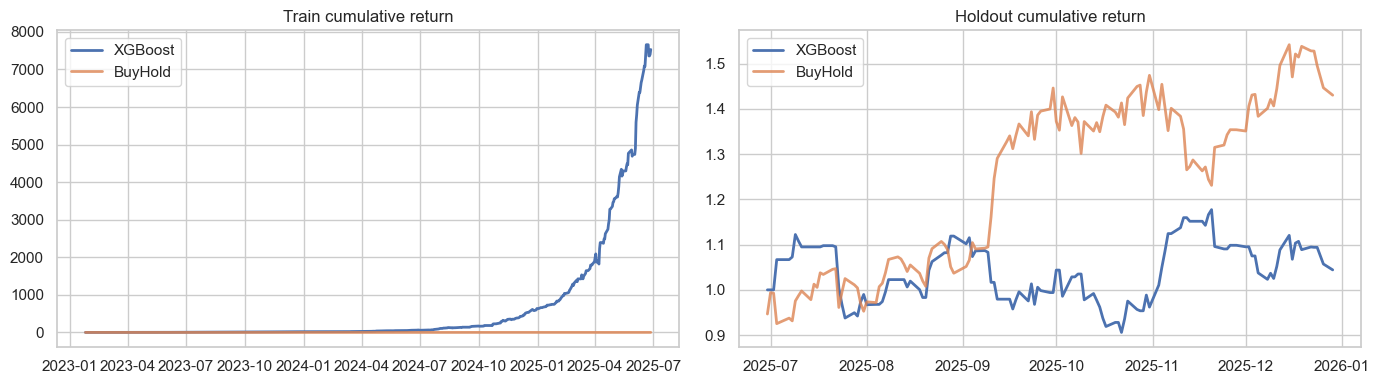

Saved search results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_search_results.csv
Saved per-family comparison to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_model_comparison.csv
Saved rolling window results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_rolling_window_results.csv
Saved metrics to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_metrics.csv
Saved test predictions to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_tree_models_v10_test_predictions.csv
Saved selected features to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_directi

In [11]:
search_rows = []
config_counter = 0

print(
    f"Starting rolling search: {len(MODEL_CONFIGS)} model configs x {configs_per_model} setup variants = {total_candidate_configs} total candidates"
)

for model_idx, model_config in enumerate(MODEL_CONFIGS, start=1):
    model_name = model_config["model_name"]
    model_params = model_config["params"]
    print(f"[Model {model_idx}/{len(MODEL_CONFIGS)}] family={model_name}, params={model_params}")
    for local_config_idx, (top_k_move, top_k_dir, move_prob_thr, dir_prob_thr) in enumerate(product(
        TOP_K_MOVE_VALUES,
        TOP_K_DIR_VALUES,
        MOVE_PROB_THRESHOLDS,
        DIR_PROB_THRESHOLDS,
    ), start=1):
        config_counter += 1
        print(
            f"  [Config {config_counter}/{total_candidate_configs}] model_setup={local_config_idx}/{configs_per_model} "
            f"top_k_move={top_k_move}, top_k_dir={top_k_dir}, move_thr={move_prob_thr:.2f}, dir_thr={dir_prob_thr:.2f}"
        )
        window_rows = []
        for window_id, window in enumerate(rolling_windows, start=1):
            if window_id == 1 or window_id == len(rolling_windows) or window_id % 5 == 0:
                print(f"    window {window_id}/{len(rolling_windows)}")
            bundle = fit_two_stage_bundle(
                window["train_df"],
                model_name=model_name,
                model_params=model_params,
                top_k_move=top_k_move,
                top_k_dir=top_k_dir,
                move_band=MOVE_BAND,
            )
            if bundle is None:
                continue
            scored = predict_two_stage(
                bundle,
                window["test_df"],
                move_prob_thr=move_prob_thr,
                dir_prob_thr=dir_prob_thr,
            )
            stats = perf_stats(scored)
            window_rows.append(
                {
                    "window_id": window_id,
                    "train_start": window["train_start"].date(),
                    "train_end": (window["train_end"] - pd.Timedelta(days=1)).date(),
                    "test_start": window["test_start"].date(),
                    "test_end": (window["test_end"] - pd.Timedelta(days=1)).date(),
                    "move_rows_train": int((window["train_df"]["future_return_1d"].abs() > MOVE_BAND).sum()),
                    **stats,
                }
            )

        if not window_rows:
            print("    no valid rolling windows for this configuration")
            continue

        rolling_df = pd.DataFrame(window_rows)
        mean_active = rolling_df["active_pct"].mean()
        mean_hit = rolling_df["hit_rate_active"].dropna().mean() if rolling_df["hit_rate_active"].notna().any() else 0.0
        profitable_pct = float((rolling_df["cum_return"] > 0).mean())
        activity_penalty = max(0.0, TARGET_ACTIVE_PCT - mean_active) * 1.5
        rolling_score = (
            0.35 * rolling_df["sharpe"].mean()
            + 0.25 * rolling_df["cum_return"].median()
            + 0.20 * (profitable_pct - 0.5)
            + 0.20 * (mean_hit - 0.5)
            - activity_penalty
        )

        search_rows.append(
            {
                "model_name": model_name,
                "model_params": json.dumps(model_params, sort_keys=True),
                "move_band": MOVE_BAND,
                "top_k_move": top_k_move,
                "top_k_dir": top_k_dir,
                "move_prob_thr": move_prob_thr,
                "dir_prob_thr": dir_prob_thr,
                "rolling_score": float(rolling_score),
                "rolling_mean_cum_return": float(rolling_df["cum_return"].mean()),
                "rolling_median_cum_return": float(rolling_df["cum_return"].median()),
                "rolling_mean_sharpe": float(rolling_df["sharpe"].mean()),
                "rolling_mean_active_pct": float(mean_active),
                "rolling_mean_hit_rate": float(mean_hit),
                "rolling_profitable_window_pct": float(profitable_pct),
                "n_windows": int(len(rolling_df)),
            }
        )
        print(
            f"    done: score={rolling_score:.4f}, mean_cum_return={rolling_df['cum_return'].mean():.4f}, "
            f"mean_active_pct={mean_active:.4f}, profitable_windows={int((rolling_df['cum_return'] > 0).sum())}/{len(rolling_df)}"
        )


search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
print("Rolling search complete.")
search_path = output_dir / "stock_direction_tree_models_v10_search_results.csv"
search_df.to_csv(search_path, index=False)

best_per_family = (
    search_df.sort_values(["model_name", "rolling_score"], ascending=[True, False])
    .groupby("model_name", as_index=False)
    .first()
    .sort_values("rolling_score", ascending=False)
    .reset_index(drop=True)
)
comparison_path = output_dir / "stock_direction_tree_models_v10_model_comparison.csv"
best_per_family.to_csv(comparison_path, index=False)

display(best_per_family)

best_row = search_df.iloc[0].to_dict()
best_model_name = best_row["model_name"]
best_model_params = json.loads(best_row["model_params"])

print(
    f"Best overall -> model={best_model_name}, top_k_move={best_row['top_k_move']}, "
    f"top_k_dir={best_row['top_k_dir']}, move_prob_thr={best_row['move_prob_thr']}, "
    f"dir_prob_thr={best_row['dir_prob_thr']}"
)
print(f"Params: {best_model_params}")
print(f"Rolling score: {best_row['rolling_score']:.4f}")

print("Re-running best configuration across all rolling windows...")
best_window_rows = []
for window_id, window in enumerate(rolling_windows, start=1):
    if window_id == 1 or window_id == len(rolling_windows) or window_id % 5 == 0:
        print(f"  best-config window {window_id}/{len(rolling_windows)}")
    bundle = fit_two_stage_bundle(
        window["train_df"],
        model_name=best_model_name,
        model_params=best_model_params,
        top_k_move=int(best_row["top_k_move"]),
        top_k_dir=int(best_row["top_k_dir"]),
        move_band=float(best_row["move_band"]),
    )
    scored = predict_two_stage(
        bundle,
        window["test_df"],
        move_prob_thr=float(best_row["move_prob_thr"]),
        dir_prob_thr=float(best_row["dir_prob_thr"]),
    )
    stats = perf_stats(scored)
    best_window_rows.append(
        {
            "window_id": window_id,
            "train_start": window["train_start"].date(),
            "train_end": (window["train_end"] - pd.Timedelta(days=1)).date(),
            "test_start": window["test_start"].date(),
            "test_end": (window["test_end"] - pd.Timedelta(days=1)).date(),
            "move_rows_train": int((window["train_df"]["future_return_1d"].abs() > MOVE_BAND).sum()),
            **stats,
        }
    )

rolling_results_df = pd.DataFrame(best_window_rows)
rolling_results_path = output_dir / "stock_direction_tree_models_v10_rolling_window_results.csv"
rolling_results_df.to_csv(rolling_results_path, index=False)

print("Fitting best configuration on final training split...")
final_bundle = fit_two_stage_bundle(
    final_train,
    model_name=best_model_name,
    model_params=best_model_params,
    top_k_move=int(best_row["top_k_move"]),
    top_k_dir=int(best_row["top_k_dir"]),
    move_band=float(best_row["move_band"]),
)

print("Scoring final train and holdout splits...")
train_scored = predict_two_stage(
    final_bundle,
    final_train,
    move_prob_thr=float(best_row["move_prob_thr"]),
    dir_prob_thr=float(best_row["dir_prob_thr"]),
)
test_scored = predict_two_stage(
    final_bundle,
    final_test,
    move_prob_thr=float(best_row["move_prob_thr"]),
    dir_prob_thr=float(best_row["dir_prob_thr"]),
)

buyhold_train = final_train.copy()
buyhold_train["signal"] = 1
buyhold_train["strategy_return"] = buyhold_train["future_return_1d"]
buyhold_train["trade_true_dir"] = np.where(buyhold_train["future_return_1d"] > 0, 1.0, 0.0)

buyhold_test = final_test.copy()
buyhold_test["signal"] = 1
buyhold_test["strategy_return"] = buyhold_test["future_return_1d"]
buyhold_test["trade_true_dir"] = np.where(buyhold_test["future_return_1d"] > 0, 1.0, 0.0)

metrics_rows = [
    {"model": "BuyHold", "split": "train", **perf_stats(buyhold_train)},
    {"model": "BuyHold", "split": "test", **perf_stats(buyhold_test)},
    {"model": best_model_name, "split": "train", **perf_stats(train_scored)},
    {"model": best_model_name, "split": "test", **perf_stats(test_scored)},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = output_dir / "stock_direction_tree_models_v10_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

predictions_path = output_dir / "stock_direction_tree_models_v10_test_predictions.csv"
test_scored[
    [
        "date",
        "future_return_1d",
        "y_dir",
        "p_move",
        "p_up",
        "signal",
        "trade_executed",
        "strategy_return",
        "trade_true_dir",
    ]
].to_csv(predictions_path, index=False)

selected_features_df = pd.DataFrame(extract_feature_rows(final_bundle))
selected_features_df["model_name"] = best_model_name
selected_features_df["model_params"] = json.dumps(best_model_params, sort_keys=True)
selected_features_path = output_dir / "stock_direction_tree_models_v10_selected_features.csv"
selected_features_df.to_csv(selected_features_path, index=False)

display(metrics_df)
display(rolling_results_df.head())
display(selected_features_df)

print("Preparing classification report and plots...")
active_test = test_scored[test_scored["signal"] != 0].copy()
if len(active_test):
    y_true_active = active_test["trade_true_dir"].astype(int)
    y_pred_active = np.where(active_test["signal"] == 1, 1, 0)
    print("Classification report on active trades:")
    print(classification_report(y_true_active, y_pred_active, digits=4))
else:
    print("No active trades on the final holdout.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, frame, title in [
    (axes[0], train_scored, "Train cumulative return"),
    (axes[1], test_scored, "Holdout cumulative return"),
]:
    equity = (1 + frame["strategy_return"].fillna(0.0)).cumprod()
    buyhold = (1 + frame["future_return_1d"].fillna(0.0)).cumprod()
    ax.plot(frame["date"], equity, label=best_model_name, linewidth=2)
    ax.plot(frame["date"], buyhold, label="BuyHold", linewidth=2, alpha=0.8)
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Saved search results to {search_path}")
print(f"Saved per-family comparison to {comparison_path}")
print(f"Saved rolling window results to {rolling_results_path}")
print(f"Saved metrics to {metrics_path}")
print(f"Saved test predictions to {predictions_path}")
print(f"Saved selected features to {selected_features_path}")